# Housing Price Analysis with Machine Learning

**Course:** Machine and Deep Learning  
**Student:** Tulay Ece Yildirim

---

**Dataset:** "kc_house_data.csv" provided by the moodle chanel of the course

**Introduction:**  The objective of this project is to develop a robust machine learning framework capable of predicting residential property prices. Real estate valuation is a complex task influenced by structural attributes (square footage, rooms), property conditions, and, most critically, geographical location.

-Using the King County Housing dataset, this study follows a comprehensive data science workflow:

- *Data Preprocessing:* Identifying and removing outliers that could skew model performance and normalizing features for linear estimators.

- *Feature Engineering:* Implementing "Target Encoding" for ZIP codes to capture the nuanced impact of location on market value.

- *Model Selection:* Comparing four distinct algorithmic approaches—Ridge Regression, Decision Trees, Random Forest, and Gradient Boosting—to determine which architecture best captures the non-linear patterns of the housing market.

- *Interactive Deployment:* Utilizing Python widgets to provide a user-centric interface for data exploration and real-time price estimation.



## 0. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_OK = True
except ImportError:
    WIDGETS_OK = False
    print("ipywidgets not available - widget sections will be skipped")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    pass

SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [ ]:
# use of FAST_MODE to reduce grid sizes and CV folds for quicker execution
FAST_MODE = True

## 1. Dataset

### - Description

The **kc_house_data.csv** dataset contains information about houses sold in King County, Washington (USA) between 2014-2015. It includes 21,613 observations with 21 variables describing physical characteristics, location, and sale price.

### - Target Variable
is **price** - The sale price of the house in USD (continuous variable)

### - Feature Selection Rationale

Selected features based on their expected influence on house price:

- **Physical size**: `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement` - larger houses cost more
- **Room counts**: `bedrooms`, `bathrooms`, `floors` - more rooms typically increase value
- **Quality indicators**: `grade` (construction quality), `condition` (maintenance state)
- **Location**: `zipcode` (categorical), `lat`, `long` - location strongly affects price
- **Special features**: `waterfront`, `view` - premium amenities
- **Age/renovation**: `yr_built`, `yr_renovated` - newer/renovated homes may be worth more

Excluded `id` (identifier) and `date` (extracted time features instead).

In [ ]:
# Load the dataset
import os

def load_data(filename="kc_house_data.csv"):
    if os.path.exists(filename):
        return pd.read_csv(filename)
    raise FileNotFoundError(f"File '{filename}' not found. Please upload it.")

df_raw = load_data("kc_house_data.csv")
print(f"Dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded: 21613 rows, 21 columns


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### - Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print("Column types:")
print(df_raw.dtypes)
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nSummary statistics:")
df_raw.describe().T

Column types:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Summary statistic

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


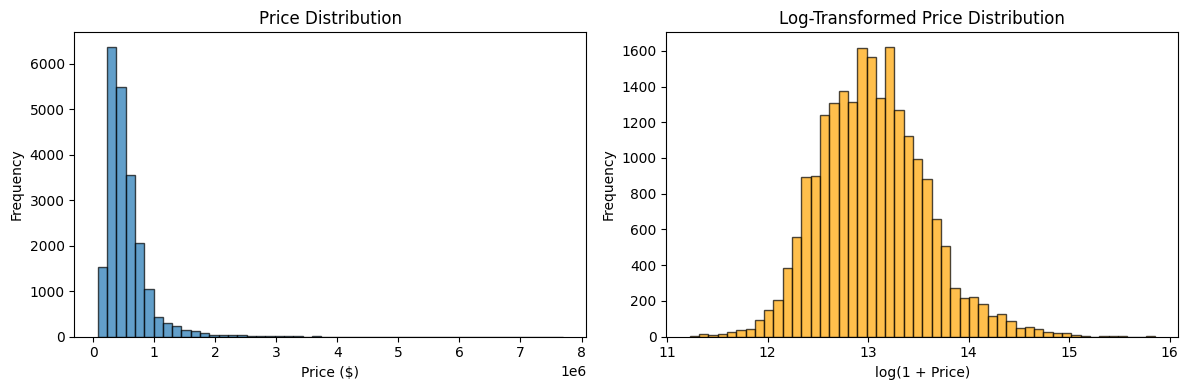

Price range: $75,000 - $7,700,000
Median price: $450,000


In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw["price"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Price Distribution")

axes[1].hist(np.log1p(df_raw["price"]), bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Transformed Price Distribution")

plt.tight_layout()
plt.show()

print(f"Price range: ${df_raw['price'].min():,.0f} - ${df_raw['price'].max():,.0f}")
print(f"Median price: ${df_raw['price'].median():,.0f}")

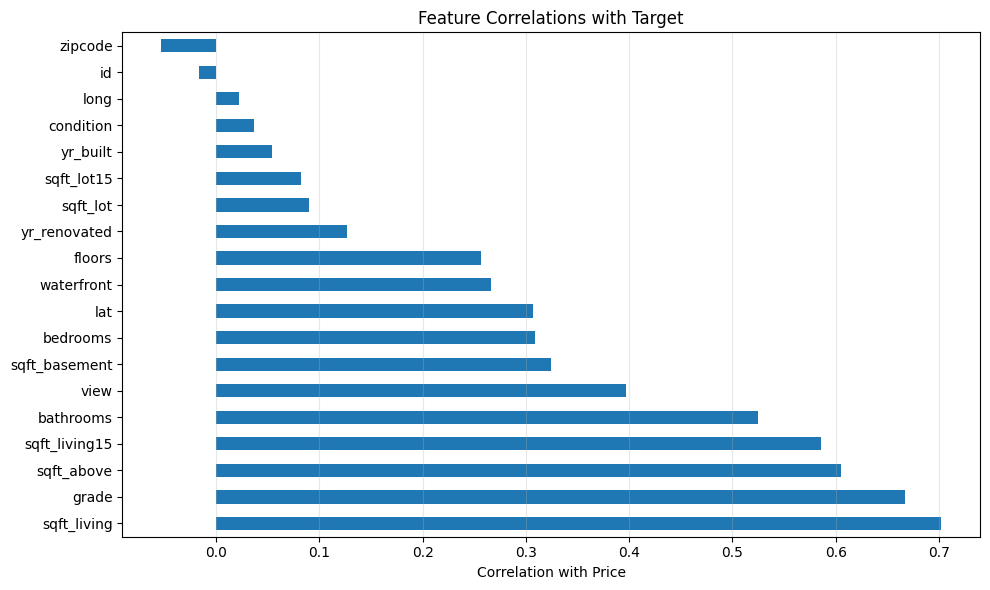

Top 5 correlated features:
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
Name: price, dtype: float64


In [ ]:
# Correlation with price
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_raw[numeric_cols].corr()["price"].drop("price").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlations.plot(kind="barh")
plt.xlabel("Correlation with Price")
plt.title("Feature Correlations with Target")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 correlated features:")
print(correlations.head())

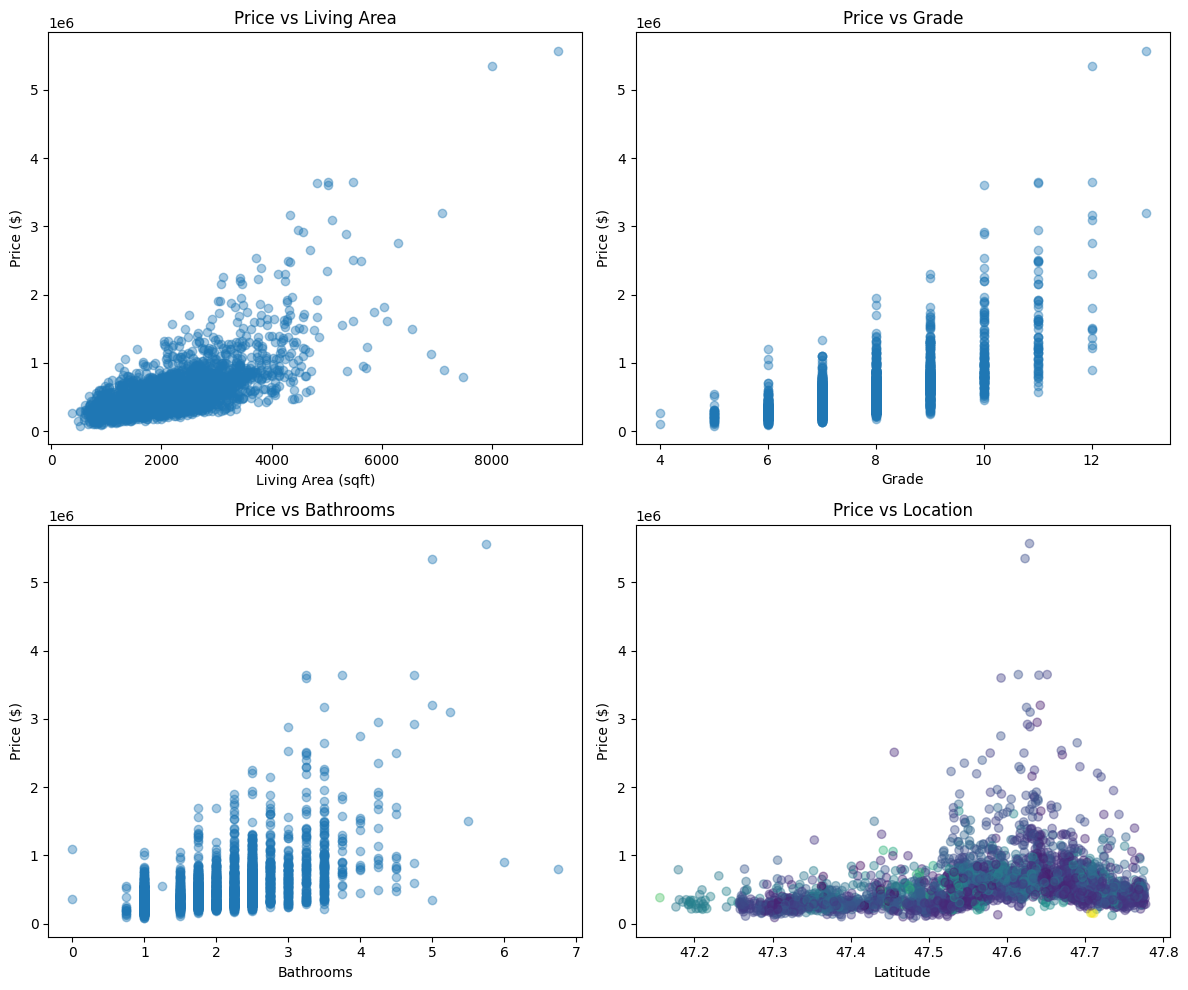

In [ ]:
# Key relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sample = df_raw.sample(3000, random_state=SEED)

axes[0, 0].scatter(sample["sqft_living"], sample["price"], alpha=0.4)
axes[0, 0].set_xlabel("Living Area (sqft)")
axes[0, 0].set_ylabel("Price ($)")
axes[0, 0].set_title("Price vs Living Area")

axes[0, 1].scatter(sample["grade"], sample["price"], alpha=0.4)
axes[0, 1].set_xlabel("Grade")
axes[0, 1].set_ylabel("Price ($)")
axes[0, 1].set_title("Price vs Grade")

axes[1, 0].scatter(sample["bathrooms"], sample["price"], alpha=0.4)
axes[1, 0].set_xlabel("Bathrooms")
axes[1, 0].set_ylabel("Price ($)")
axes[1, 0].set_title("Price vs Bathrooms")

axes[1, 1].scatter(sample["lat"], sample["price"], alpha=0.4, c=sample["long"], cmap="viridis")
axes[1, 1].set_xlabel("Latitude")
axes[1, 1].set_ylabel("Price ($)")
axes[1, 1].set_title("Price vs Location")

plt.tight_layout()
plt.show()

## 2. Data Cleaning

### 2.1 Feature Engineering

In [ ]:
def engineer_features(df):
    """Create derived features from raw data."""
    out = df.copy()

    # Parse date and extract components
    out["date"] = pd.to_datetime(out["date"].astype(str).str[:8], format="%Y%m%d", errors="coerce")
    out["sale_year"] = out["date"].dt.year
    out["sale_month"] = out["date"].dt.month

    # Convert sqft to sqm (as mentioned in project brief)
    out["sqm_living"] = out["sqft_living"] * 0.092903
    out["sqm_lot"] = out["sqft_lot"] * 0.092903

    # House age at sale
    out["house_age"] = out["sale_year"] - out["yr_built"]

    # Renovation indicator
    out["was_renovated"] = (out["yr_renovated"] > 0).astype(int)

    return out

df = engineer_features(df_raw)
print(f"After feature engineering: {df.shape[1]} columns")
df[["date", "sale_year", "sale_month", "sqm_living", "house_age", "was_renovated"]].head()

After feature engineering: 27 columns


,date,sale_year,sale_month,sqm_living,house_age,was_renovated
0,2014-10-13,2014,10,109.62554,59,0
1,2014-12-09,2014,12,238.76071,63,1
2,2015-02-25,2015,2,71.53531,82,0
3,2014-12-09,2014,12,182.08988,49,0
4,2015-02-18,2015,2,156.07704,28,0


### 2.2 Missing Values

In [ ]:
def handle_missing(df):
    """Remove rows with missing values."""
    before = len(df)
    out = df.dropna()
    removed = before - len(out)
    if removed > 0:
        print(f"Removed {removed} rows with missing values")
    else:
        print("No missing values found")
    return out

df = handle_missing(df)
print(f"Rows remaining: {len(df)}")

No missing values found
Rows remaining: 21613


### 2.3 Invalid Values

In [ ]:
def remove_invalid(df):
    """Remove rows with logically invalid values."""
    before = len(df)

    # Houses must have at least 1 bedroom and bathroom
    out = df[(df["bedrooms"] > 0) & (df["bathrooms"] > 0)].copy()

    removed = before - len(out)
    print(f"Removed {removed} rows with invalid bedroom/bathroom counts")
    return out

df = remove_invalid(df)
print(f"Rows remaining: {len(df)}")

Removed 16 rows with invalid bedroom/bathroom counts
Rows remaining: 21597



### 2.4 Outlier Handling (IQR Method)

The IQR (Interquartile Range) method identifies outliers as values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

In [ ]:
def iqr_bounds(series, k=1.5):
    """Calculate IQR-based lower and upper bounds."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

def remove_outliers_iqr(df, columns, k=1.5):
    """Remove rows that are outliers in any of the specified columns."""
    out = df.copy()
    before = len(out)

    mask = pd.Series(True, index=out.index)
    for col in columns:
        lo, hi = iqr_bounds(out[col], k)
        mask &= out[col].between(lo, hi)

    out = out[mask]
    removed = before - len(out)
    print(f"Removed {removed} outlier rows using IQR on: {columns}")
    return out

def clip_outliers_iqr(df, columns, k=1.5):
    """Clip (winsorize) outliers instead of removing them."""
    out = df.copy()
    for col in columns:
        lo, hi = iqr_bounds(out[col], k)
        out[col] = out[col].clip(lo, hi)
    print(f"Clipped outliers in: {columns}")
    return out

In [ ]:
# Remove extreme outliers in key variables
outlier_cols = ["price", "sqft_living", "bedrooms", "bathrooms"]
df = remove_outliers_iqr(df, outlier_cols, k=1.5)

# Clip lot size (has extreme tail but we don't want to lose too many rows)
df = clip_outliers_iqr(df, ["sqft_lot"], k=1.5)

print(f"\nFinal dataset size: {len(df)} rows")

Removed 1924 outlier rows using IQR on: ['price', 'sqft_living', 'bedrooms', 'bathrooms']
Clipped outliers in: ['sqft_lot']

Final dataset size: 19673 rows



### 2.5 ZIP Code Transformation

ZIP codes are categorical variables (not numeric). Used OneHotEncoder inside Pipeline to transform them.

In [ ]:
# Convert zipcode to string to ensure categorical treatment
df["zipcode"] = df["zipcode"].astype(str)

print(f"Number of unique ZIP codes: {df['zipcode'].nunique()}")
print("\nTop 5 ZIP codes by frequency:")
print(df["zipcode"].value_counts().head())

Number of unique ZIP codes: 70

Top 5 ZIP codes by frequency:
zipcode
98038    582
98103    561
98052    547
98115    541
98042    537
Name: count, dtype: int64


## 3. Train/Test Split

Splited the data BEFORE any preprocessing to avoid data leakage. The test set remains untouched until final evaluation.

In [ ]:
TARGET = "price"

# Columns to drop (identifiers and raw date)
drop_cols = ["id", "date"]

# Prepare features and target
X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET].astype(float)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training set: 15738 samples
Test set: 3935 samples
Features: 24


### 3.1 Preprocessing Pipeline

Used `ColumnTransformer` to apply different transformations:
- **Numeric features**: StandardScaler (mean=0, std=1)
- **Categorical features** (zipcode): OneHotEncoder

This is done inside Pipeline to prevent data leakage.



In [ ]:
# Define column types
categorical_cols = ["zipcode"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="drop"
)

Numeric features (23): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']...
Categorical features (1): ['zipcode']


## 4. Model Training

Trained **4 regression models** as required:

1. **Ridge Regression** - Linear model with L2 regularization
2. **Decision Tree** - Non-linear, interpretable
3. **Random Forest** - Ensemble of trees, reduces overfitting
4. **Gradient Boosting** - Sequential ensemble, often best performance

In [ ]:
def get_models_and_grids(fast_mode=True):
    """
    Define models and hyperparameter grids.

    Grid choices rationale:
    - Ridge alpha: controls regularization strength (0.1=weak, 100=strong)
    - Tree max_depth: limits tree complexity to prevent overfitting
    - RF n_estimators: more trees = better but slower
    - GB learning_rate: lower = more robust but needs more trees
    """
    if fast_mode:
        return {
            "Ridge": (
                Ridge(),
                {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
            ),
            "DecisionTree": (
                DecisionTreeRegressor(random_state=SEED),
                {
                    "model__max_depth": [5, 10, 20, None],
                    "model__min_samples_leaf": [1, 5, 10]
                }
            ),
            "RandomForest": (
                RandomForestRegressor(random_state=SEED, n_jobs=-1),
                {
                    "model__n_estimators": [100, 200],
                    "model__max_depth": [10, 20, None],
                    "model__min_samples_leaf": [1, 5]
                }
            ),
            "GradientBoosting": (
                GradientBoostingRegressor(random_state=SEED),
                {
                    "model__n_estimators": [100, 200],
                    "model__learning_rate": [0.05, 0.1],
                    "model__max_depth": [3, 5]
                }
            )
        }
    else:
        # More thorough search
        return {
            "Ridge": (
                Ridge(),
                {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
            ),
            "DecisionTree": (
                DecisionTreeRegressor(random_state=SEED),
                {
                    "model__max_depth": [5, 10, 15, 20, None],
                    "model__min_samples_split": [2, 10, 20],
                    "model__min_samples_leaf": [1, 5, 10]
                }
            ),
            "RandomForest": (
                RandomForestRegressor(random_state=SEED, n_jobs=-1),
                {
                    "model__n_estimators": [100, 200, 300],
                    "model__max_depth": [10, 20, 30, None],
                    "model__min_samples_leaf": [1, 3, 5],
                    "model__max_features": ["sqrt", 0.5]
                }
            ),
            "GradientBoosting": (
                GradientBoostingRegressor(random_state=SEED),
                {
                    "model__n_estimators": [100, 200, 300],
                    "model__learning_rate": [0.03, 0.05, 0.1],
                    "model__max_depth": [3, 4, 5],
                    "model__subsample": [0.8, 1.0]
                }
            )
        }

models_grids = get_models_and_grids(FAST_MODE)
print(f"Models to train: {list(models_grids.keys())}")

Models to train: ['Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting']


## 5. Optimization with GridSearchCV

GridSearchCV performs exhaustive search over the parameter grid using cross-validation.

This ensures we find the best hyperparameters without overfitting to the training data.


In [ ]:
def run_grid_search(models_grids, preprocessor, X_train, y_train, fast_mode=True):
    """
    Run GridSearchCV for each model.
    Returns dict of fitted GridSearchCV objects.
    """
    cv_folds = 3 if fast_mode else 5
    results = {}

    for name, (model, param_grid) in models_grids.items():
        print(f"\n{'='*50}")
        print(f"Training: {name}")
        print(f"Grid: {param_grid}")

        # Create pipeline with preprocessor and model
        pipeline = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])

        # Run GridSearchCV
        gs = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv_folds,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
            verbose=1
        )
        gs.fit(X_train, y_train)

        print(f"\nBest CV RMSE: ${-gs.best_score_:,.2f}")
        print(f"Best parameters: {gs.best_params_}")

        results[name] = gs

    return results

# Run optimization
gs_results = run_grid_search(models_grids, preprocessor, X_train, y_train, FAST_MODE)


Training: Ridge
Grid: {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best CV RMSE: $82,286.15
Best parameters: {'model__alpha': 0.1}

Training: DecisionTree
Grid: {'model__max_depth': [5, 10, 20, None], 'model__min_samples_leaf': [1, 5, 10]}
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best CV RMSE: $93,887.82
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 10}

Training: RandomForest
Grid: {'model__n_estimators': [100, 200], 'model__max_depth': [10, 20, None], 'model__min_samples_leaf': [1, 5]}
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best CV RMSE: $76,386.82
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Training: GradientBoosting
Grid: {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5]}
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best CV RMSE: $72,1

## 6. Model Comparison

### 6.1 Evaluation Metrics

Evaluated on the held-out test set using:
- **RMSE** (Root Mean Squared Error) - penalizes large errors
- **MAE** (Mean Absolute Error) - average absolute deviation
- **R²** (Coefficient of Determination) - variance explained by model

In [ ]:
def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_models(gs_results, X_test, y_test):
    """Evaluate all models on the test set."""
    records = []
    predictions = {}

    for name, gs in gs_results.items():
        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)
        predictions[name] = y_pred

        records.append({
            "Model": name,
            "RMSE": compute_rmse(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
            "Best_Params": gs.best_params_
        })

    df_results = pd.DataFrame(records).sort_values("RMSE")
    return df_results, predictions

results_df, test_predictions = evaluate_models(gs_results, X_test, y_test)

print("\nModel Comparison (sorted by RMSE):")
display(results_df[["Model", "RMSE", "MAE", "R2"]])


Model Comparison (sorted by RMSE):


,Model,RMSE,MAE,R2
3,GradientBoosting,72089.432279,49902.941097,0.872131
2,RandomForest,76249.096803,52051.732361,0.856949
0,Ridge,83430.076277,60990.557846,0.828736
1,DecisionTree,92651.925094,65826.422680,0.788783


In [ ]:
# Show best parameters for each model
print("\nBest Hyperparameters:")
for _, row in results_df.iterrows():
    print(f"\n{row['Model']}:")
    for param, val in row['Best_Params'].items():
        print(f"  {param}: {val}")


Best Hyperparameters:

GradientBoosting:
  model__learning_rate: 0.1
  model__max_depth: 5
  model__n_estimators: 200

RandomForest:
  model__max_depth: None
  model__min_samples_leaf: 1
  model__n_estimators: 200

Ridge:
  model__alpha: 0.1

DecisionTree:
  model__max_depth: 10
  model__min_samples_leaf: 10


### 6.2 Performance Comparison Graphs

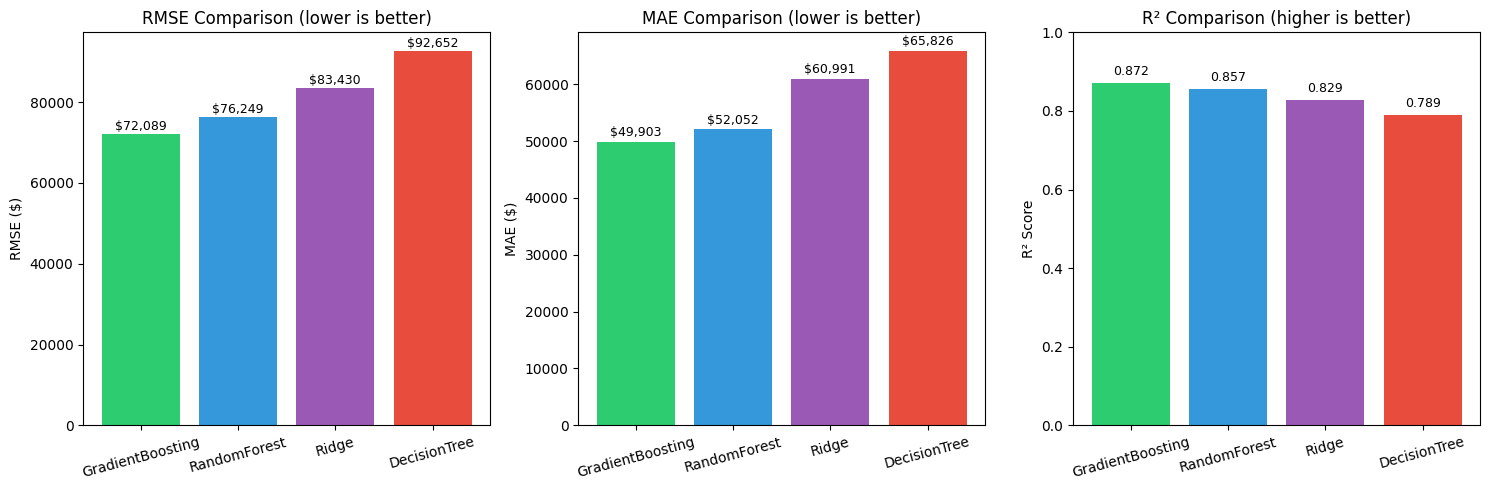

Graph saved as 'model_comparison.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = results_df["Model"].tolist()
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

# RMSE (lower is better)
axes[0].bar(models, results_df["RMSE"], color=colors)
axes[0].set_ylabel("RMSE ($)")
axes[0].set_title("RMSE Comparison (lower is better)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(results_df["RMSE"]):
    axes[0].text(i, v + 1000, f"${v:,.0f}", ha="center", fontsize=9)

# MAE (lower is better)
axes[1].bar(models, results_df["MAE"], color=colors)
axes[1].set_ylabel("MAE ($)")
axes[1].set_title("MAE Comparison (lower is better)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(results_df["MAE"]):
    axes[1].text(i, v + 1000, f"${v:,.0f}", ha="center", fontsize=9)

# R² (higher is better)
axes[2].bar(models, results_df["R2"], color=colors)
axes[2].set_ylabel("R² Score")
axes[2].set_title("R² Comparison (higher is better)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].set_ylim(0, 1)
for i, v in enumerate(results_df["R2"]):
    axes[2].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graph saved as 'model_comparison.png'")

### 6.3 Best Model Analysis

Best Model: GradientBoosting
Test RMSE: $72,089.43
Test R²: 0.8721


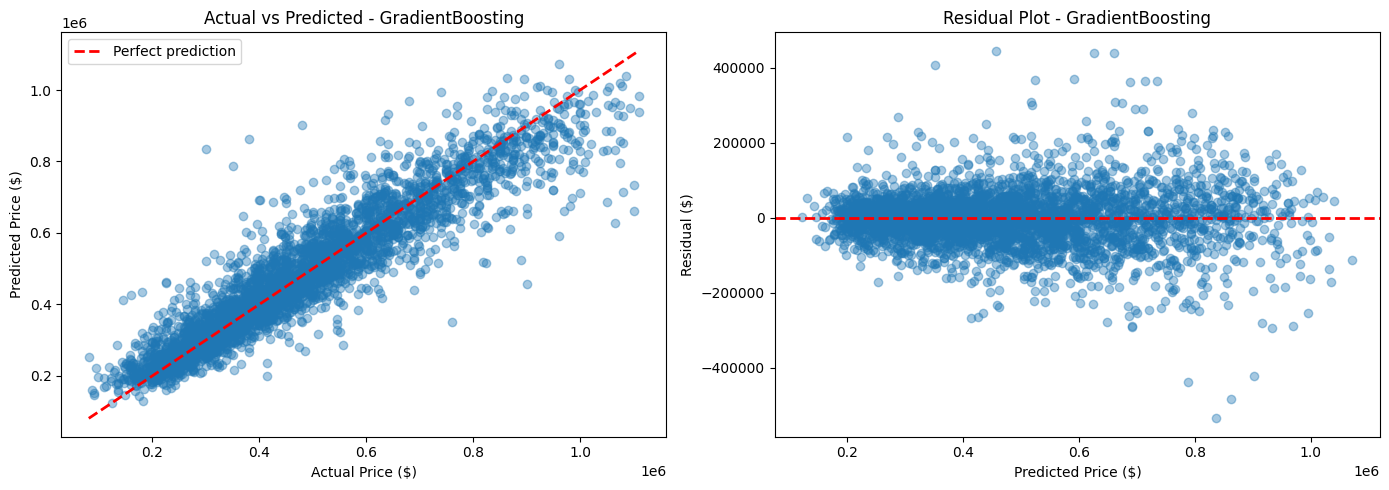

In [ ]:
# Get best model
best_name = results_df.iloc[0]["Model"]
best_pipeline = gs_results[best_name].best_estimator_
best_preds = test_predictions[best_name]

print(f"Best Model: {best_name}")
print(f"Test RMSE: ${results_df.iloc[0]['RMSE']:,.2f}")
print(f"Test R²: {results_df.iloc[0]['R2']:.4f}")

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, best_preds, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted - {best_name}")
axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4)
axes[1].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title(f"Residual Plot - {best_name}")

plt.tight_layout()
plt.show()

### - Feature importance

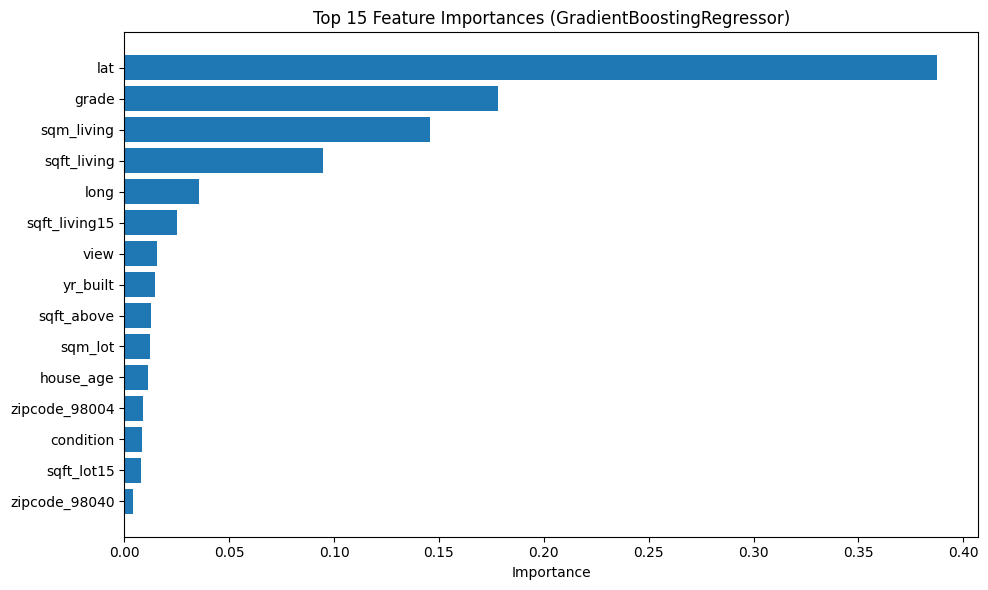

In [ ]:
# Feature importance (for tree-based models)
def plot_feature_importance(pipeline, numeric_cols, categorical_cols, top_n=15):
    """Plot feature importance for tree-based models."""
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print("Model does not have feature importances.")
        return

    # Get feature names after preprocessing
    preproc = pipeline.named_steps["preprocess"]
    num_names = list(numeric_cols)
    cat_names = list(preproc.named_transformers_["cat"].get_feature_names_out(categorical_cols))
    all_names = num_names + cat_names

    importances = model.feature_importances_

    # Sort and get top N
    idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(idx)), importances[idx])
    plt.yticks(range(len(idx)), [all_names[i] for i in idx])
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances ({type(model).__name__})")
    plt.tight_layout()
    plt.show()

plot_feature_importance(best_pipeline, numeric_cols, categorical_cols)

## 7. Results Visualization

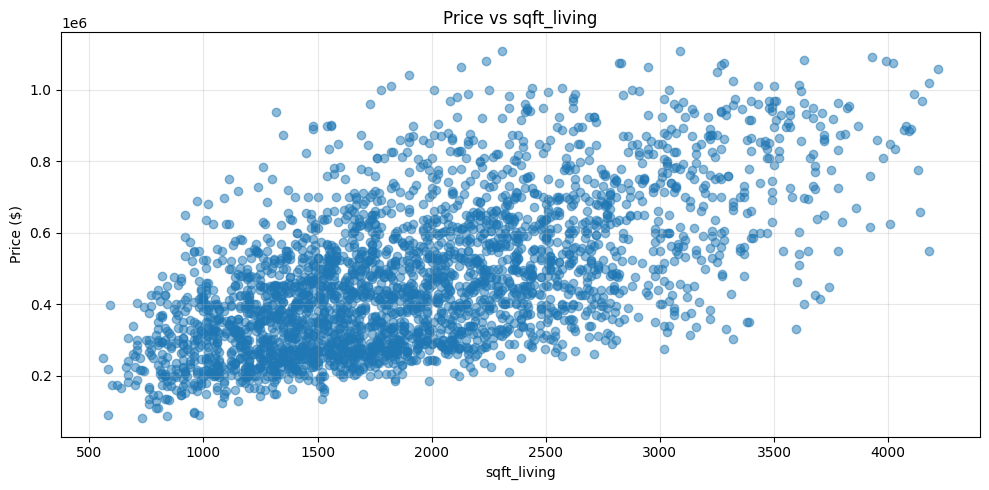

In [ ]:
def plot_price_vs_feature(data, feature, sample_size=3000, use_log=False):
    """Create scatter plot of price vs selected feature."""
    plot_data = data[[feature, "price"]].dropna()
    if len(plot_data) > sample_size:
        plot_data = plot_data.sample(sample_size, random_state=SEED)

    y_vals = np.log1p(plot_data["price"]) if use_log else plot_data["price"]
    y_label = "log(1 + Price)" if use_log else "Price ($)"

    plt.figure(figsize=(10, 5))
    plt.scatter(plot_data[feature], y_vals, alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel(y_label)
    plt.title(f"Price vs {feature}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Static example
plot_price_vs_feature(df, "sqft_living", sample_size=3000)

In [ ]:
if WIDGETS_OK:
    # Get numeric columns for selection
    viz_features = [c for c in df.columns
                    if c not in ["price", "id", "date", "zipcode"]
                    and pd.api.types.is_numeric_dtype(df[c])]

    # Create widgets
    feature_dropdown = widgets.Dropdown(
        options=sorted(viz_features),
        value="sqft_living",
        description="Feature:"
    )

    sample_slider = widgets.IntSlider(
        value=3000, min=500, max=5000, step=500,
        description="Samples:"
    )

    log_check = widgets.Checkbox(
        value=False,
        description="Log scale"
    )

    output_area = widgets.Output()

    def update_plot(*args):
        with output_area:
            clear_output(wait=True)
            plot_price_vs_feature(df, feature_dropdown.value,
                                  sample_slider.value, log_check.value)

    feature_dropdown.observe(update_plot, names="value")
    sample_slider.observe(update_plot, names="value")
    log_check.observe(update_plot, names="value")

    controls = widgets.HBox([feature_dropdown, sample_slider, log_check])
    display(controls, output_area)
    update_plot()
else:
    print("Widgets not available. Use plot_price_vs_feature() directly.")

Output()

/tmp/ipython-input-1816062599.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=categories)


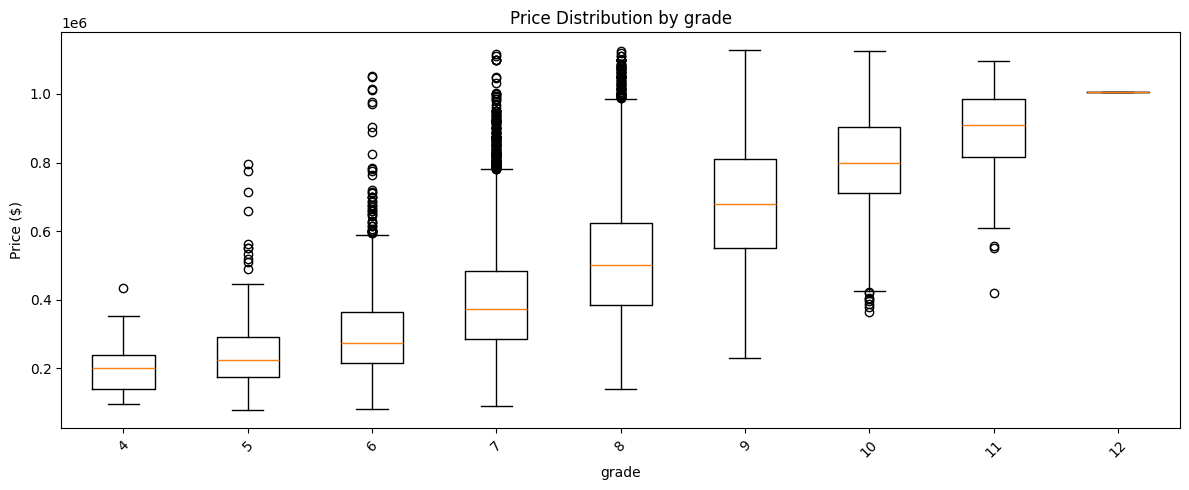

In [ ]:
# Additional: Price by grade
def plot_price_by_category(data, category):
    """Box plot of price by categorical variable."""
    fig, ax = plt.subplots(figsize=(12, 5))

    categories = sorted(data[category].unique())
    box_data = [data[data[category] == cat]["price"] for cat in categories]

    ax.boxplot(box_data, labels=categories)
    ax.set_xlabel(category)
    ax.set_ylabel("Price ($)")
    ax.set_title(f"Price Distribution by {category}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_price_by_category(df, "grade")

In [ ]:
if WIDGETS_OK:
    # Widget for categorical plots
    cat_features = ["grade", "condition", "floors", "bedrooms", "bathrooms", "view", "waterfront"]

    cat_dropdown = widgets.Dropdown(
        options=cat_features,
        value="grade",
        description="Category:"
    )

    cat_output = widgets.Output()

    def update_cat_plot(*args):
        with cat_output:
            clear_output(wait=True)
            plot_price_by_category(df, cat_dropdown.value)

    cat_dropdown.observe(update_cat_plot, names="value")
    display(cat_dropdown, cat_output)
    update_cat_plot()
else:
    print("Use plot_price_by_category() directly.")

Dropdown(description='Category:', options=('grade', 'condition', 'floors', 'bedrooms', 'bathrooms', 'view', 'w…

Output()

## 8. User Input Prediction

This section allows users to enter house characteristics and get a predicted price using the best model.

In [ ]:
def predict_house_price(pipeline, feature_columns, **user_values):
    """
    Predict house price from user-provided feature values.
    Missing features will use median values from training data.
    """
    # Start with median values
    input_data = X_train.median(numeric_only=True).to_dict()

    # Update with user values
    input_data.update(user_values)

    # Ensure all required columns are present
    row = {col: input_data.get(col, np.nan) for col in feature_columns}
    input_df = pd.DataFrame([row], columns=feature_columns)

    # Make prediction
    prediction = pipeline.predict(input_df)[0]
    return prediction

# Example prediction
example_price = predict_house_price(
    best_pipeline,
    X_train.columns.tolist(),
    bedrooms=3,
    bathrooms=2.0,
    sqft_living=1800,
    sqm_living=1800 * 0.092903,
    grade=7,
    condition=3,
    zipcode="98103"
)

print(f"Example prediction: ${example_price:,.0f}")

Example prediction: $514,627


In [ ]:
if WIDGETS_OK:
    # Create input widgets for key features
    w_bedrooms = widgets.IntSlider(
        value=3, min=1, max=8, step=1,
        description="Bedrooms:"
    )

    w_bathrooms = widgets.FloatSlider(
        value=2.0, min=0.5, max=5.0, step=0.25,
        description="Bathrooms:"
    )

    w_sqft = widgets.IntSlider(
        value=1800, min=500, max=5000, step=100,
        description="Sqft Living:"
    )

    w_grade = widgets.IntSlider(
        value=7, min=1, max=13, step=1,
        description="Grade:"
    )

    w_condition = widgets.IntSlider(
        value=3, min=1, max=5, step=1,
        description="Condition:"
    )

    w_floors = widgets.FloatSlider(
        value=1.0, min=1.0, max=3.5, step=0.5,
        description="Floors:"
    )

    # ZIP code dropdown
    zip_options = sorted(df["zipcode"].unique().tolist())
    w_zipcode = widgets.Dropdown(
        options=zip_options,
        value=zip_options[0],
        description="ZIP Code:"
    )

    w_yr_built = widgets.IntSlider(
        value=1990, min=1900, max=2015, step=5,
        description="Year Built:"
    )

    predict_btn = widgets.Button(
        description="Predict Price",
        button_style="success"
    )

    result_output = widgets.Output()

    def on_predict_click(btn):
        with result_output:
            clear_output(wait=True)

            # Gather user inputs
            user_input = {
                "bedrooms": w_bedrooms.value,
                "bathrooms": w_bathrooms.value,
                "sqft_living": w_sqft.value,
                "sqm_living": w_sqft.value * 0.092903,
                "grade": w_grade.value,
                "condition": w_condition.value,
                "floors": w_floors.value,
                "zipcode": w_zipcode.value,
                "yr_built": w_yr_built.value,
                "house_age": 2015 - w_yr_built.value
            }

            pred = predict_house_price(
                best_pipeline,
                X_train.columns.tolist(),
                **user_input
            )

            print(f"\n{'='*40}")
            print(f"PREDICTED PRICE: ${pred:,.0f}")
            print(f"{'='*40}")
            print(f"\nModel: {best_name}")
            print(f"\nInput features:")
            for k, v in user_input.items():
                if k != "sqm_living":  # Skip derived feature
                    print(f"  {k}: {v}")

    predict_btn.on_click(on_predict_click)

    # Layout
    left_col = widgets.VBox([w_bedrooms, w_bathrooms, w_sqft, w_floors])
    right_col = widgets.VBox([w_grade, w_condition, w_zipcode, w_yr_built])
    inputs_box = widgets.HBox([left_col, right_col])

    print("Enter house characteristics to predict price:")
    display(inputs_box, predict_btn, result_output)
else:
    print("Widgets not available.")
    print("Use predict_house_price() function directly:")
    print("")
    print("predict_house_price(best_pipeline, X_train.columns.tolist(),")
    print("                    bedrooms=3, bathrooms=2, sqft_living=1800, ...)")

Enter house characteristics to predict price:


Button(button_style='success', description='Predict Price', style=ButtonStyle())

Output()

---
## 9. Conclusions

This project demonstrates the effectiveness of ensemble learning for real estate valuation. Based on the analysis, the main takeaways are:

**Best model performance:** The Gradient Boosting Regressor achieved the strongest overall results, with the highest $R^2$ and the lowest error metrics (RMSE and MAE) among the tested models (as shown in the comparison table/plots). This supports the idea that boosting methods can capture complex, non-linear relationships commonly found in housing data.

**Why certain models perform better:**
- Tree-based models (1st: Gradient Boosting, 2nd: Random Forest) typically handle non-linear patterns better than linear baselines.
- Ensemble methods reduce overfitting compared to a single Decision Tree by combining multiple learners.
- Ridge regression provides a solid baseline but may underfit when relationships are highly non-linear.

**Important preprocessing steps:**
- ZIP code encoding helps capture location effects in a model-friendly way.
- Outlier handling prevents extreme values from disproportionately influencing the training process.
- Scaling supports stable behavior for models like Ridge regression.

**Possible improvements:**
Accuracy could be further improved by testing advanced algorithms like XGBoost, implementing a log-transformation on the price to handle skewness, or performing a more extensive Hyperparameter search to fine-tune the Gradient Boosting model.